## Task 1
### Part 1 - Data Preparation and Custom CNN

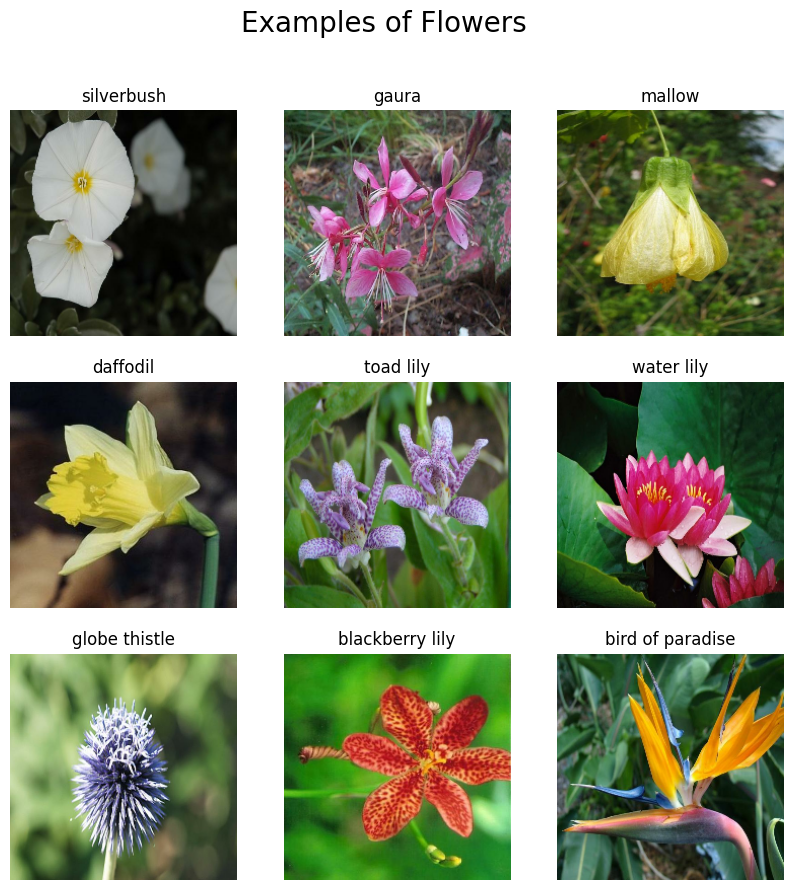

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dataset_name = 'oxford_flowers102'
(ds_train, ds_val, ds_test), ds_info = tfds.load(
    dataset_name,
    split=['train', 'validation', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

IMAGE_SIZE = 224
BATCH_SIZE = 32
num_classes = ds_info.features['label'].num_classes

def format_image(image, label):
  image = tf.cast(image, tf.float32) / 255.0
  image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
  return image, label

train_batches = ds_train.map(format_image).cache().shuffle(1000).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
val_batches = ds_val.map(format_image).cache().batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
test_batches = ds_test.map(format_image).cache().batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

class_names = ds_info.features['label'].names
plt.figure(figsize=(10, 10))
for images, labels in train_batches.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.suptitle("Examples of Flowers", fontsize=20)
plt.show()

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(IMAGE_SIZE, IMAGE_SIZE,3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # Dense Layers
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])


model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

EPOCHS = 15
history = model.fit(train_batches,
                    epochs=EPOCHS,
                    validation_data=val_batches)

loss, accuracy = model.evaluate(test_batches)
print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 102)            │        52,326 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,448,422 (169.56 MB)

 Trainable params: 44,448,422 (169.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 403ms/step - accuracy: 0.0059 - loss: 4.8432 - val_accuracy: 0.0137 - val_loss: 4.6238
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.0245 - loss: 4.5563 - val_accuracy: 0.0431 - val_loss: 4.4182
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.1235 - loss: 3.9939 - val_accuracy: 0.0637 - val_loss: 4.1762
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.4255 - loss: 2.3545 - val_accuracy: 0.1069 - val_loss: 4.3795
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.7618 - loss: 0.9520 - val_accuracy: 0.1167 - val_loss: 4.8312
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.8941 - loss: 0.4185 - val_accuracy: 0.1206 - val_loss: 5.5782
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.9431 - loss: 0.2371 - val_accuracy: 0.1049 - val_loss: 6.3683
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.9667 - loss: 0.1509 - val_accuracy: 0.0882 

**Model Arch**

I used three convolution blocks. In each block there is a 3 by 3 Conv2D layer followed by a ReLU activation. Before output, I used a MaxPooling2D layer. The number of feature channels increases with the layer index, allowing the model to learn progressively more complex and abstract features. The MaxPooling2D layers reduce the spatial dimensions of the output feature maps. After flattening, I added a Dropout layer to help prevent overfitting. Finally, a dense layer with a softmax activation outputs the probabilities for the 102 classes.

**Metrics**
- We use Sparse Categorical Crossentropy for multi-label classification task, it is a sparse variation of Crossentropy loss.
- Accuracy: The model achieved a final test accuracy of 9.35%. During training, strong signs of overfitting were evident: as the training accuracy increased, the validation loss continued to rise, leading to extremely poor performance.

### Part 2 - Transfer Learning using MobileNetV2

In [4]:
# Load MobilenetV2
base_model = tf.keras.applications.MobileNetV2(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
                                               include_top=False,
                                               weights='imagenet')

base_model.trainable = False

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

inputs = tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = inputs * 255.0
x = preprocess_input(x)
x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

mobilenet_model = tf.keras.Model(inputs, outputs)

# compile model
mobilenet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

mobilenet_model.summary()

# Training and Eval
EPOCHS_TL = 10
history_tl = mobilenet_model.fit(train_batches,
                                 epochs=EPOCHS_TL,
                                 validation_data=val_batches)

# Test
loss_tl, accuracy_tl = mobilenet_model.evaluate(test_batches)
print(f"\nMobileNetV2 Final Test Accuracy: {accuracy_tl*100:.2f}%")
print(f"MobileNetV2 Final Test Loss: {loss_tl:.4f}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 102)            │       130,662 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,388,646 (9.11 MB)

 Trainable params: 130,662 (510.40 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 794ms/step - accuracy: 0.0843 - loss: 4.3845 - val_accuracy: 0.3441 - val_loss: 3.1879
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.5745 - loss: 2.3241 - val_accuracy: 0.6176 - val_loss: 2.1137
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.8235 - loss: 1.3021 - val_accuracy: 0.7275 - val_loss: 1.6029
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9225 - loss: 0.8144 - val_accuracy: 0.7627 - val_loss: 1.3479
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9578 - loss: 0.5765 - val_accuracy: 0.7873 - val_loss: 1.1947
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9755 - loss: 0.4207 - val_accuracy: 0.7882 - val_loss: 1.0967
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9853 - loss: 0.3181 - val_accuracy: 0.8010 - val_loss: 1.0287
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9971 - loss: 0.2420 - val_accuracy: 0.8078 -

**Comparison**
Using the same metrics as the custom CNN, MobileNetV2 demonstrates much better accuracy and performance. The testing accuracy jumped from 8.9% to 76.09%, and the validation loss decreased steadily during training, showing no signs of overfitting.

**Why?**  
-  MobileNetV2 is a pretrained model based on ImageNet; it has already learned general visual features in images. We transfer that knowledge to the flower classification task.  
-  With architectural innovations, we add a **GlobalAveragePooling2D** layer before the classification layer, which reduces the number of trainable parameters from **44,448,422** to **130,662** and helps prevent overfitting.  

### Part 3 - Augmentation

In [5]:
# Custom Augmentation
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"), # Random Flipping
  tf.keras.layers.RandomRotation(0.2),      # Rotate by 20%
  tf.keras.layers.RandomZoom(0.2),        # Scaling by 20%
  tf.keras.layers.RandomContrast(0.2)       # Constrast
], name="data_augmentation")


# rebuild the model with augmentation
model_aug = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),

    # our augmentation layer
    data_augmentation,

    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Classifier
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model_aug.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Training and evaluation
EPOCHS_AUG = 20
history_aug = model_aug.fit(train_batches,
                            epochs=EPOCHS_AUG,
                            validation_data=val_batches)

# Testing
loss_aug, accuracy_aug = model_aug.evaluate(test_batches)
print(f"\nAugmented CNN Final Test Accuracy: {accuracy_aug*100:.2f}%")
print(f"Augmented CNN Final Test Loss: {loss_aug:.4f}")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - accuracy: 0.0157 - loss: 4.8421 - val_accuracy: 0.0186 - val_loss: 4.5274
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.0206 - loss: 4.4362 - val_accuracy: 0.0265 - val_loss: 4.2836
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.0451 - loss: 4.2032 - val_accuracy: 0.0824 - val_loss: 4.0164
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.0588 - loss: 4.0342 - val_accuracy: 0.1059 - val_loss: 3.8430
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.0873 - loss: 3.8075 - val_accuracy: 0.1382 - val_loss: 3.6876
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.0990 - loss: 3.6782 - val_accuracy: 0.1725 - val_loss: 3.5206
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.1176 - loss: 3.5540 - val_accuracy: 0.1657 - val_loss: 3.5124
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.1549 - loss: 3.3448 - val_accuracy: 0.1892 - val_loss

**Comparison**

With augmentations such as flipping, rotation, and scaling, the model shows a clear improvement compared to the raw custom CNN. Testing accuracy increased from 8.98% to 23.50%, and the validation loss does not increase dramatically during training.

**Why?**

Because the raw CNN model contains a huge number of parameters, it tends to memorize the exact pixel arrangement in each image. With data augmentation, the model learns more complex features such as size, orientation, and angle , which helps to prevent overfitting.

## Task 2
### Part 1 - CVAE
Most of the code refers to:
https://www.tensorflow.org/tutorials/generative/cvae


Epoch: 10, Test set ELBO: -193.93634033203125, time elapse for current epoch: 9.13s


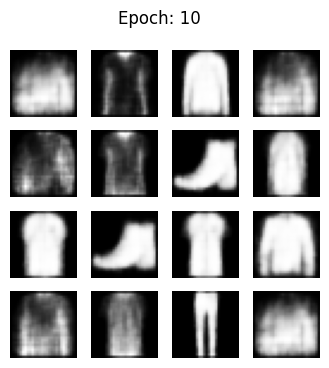

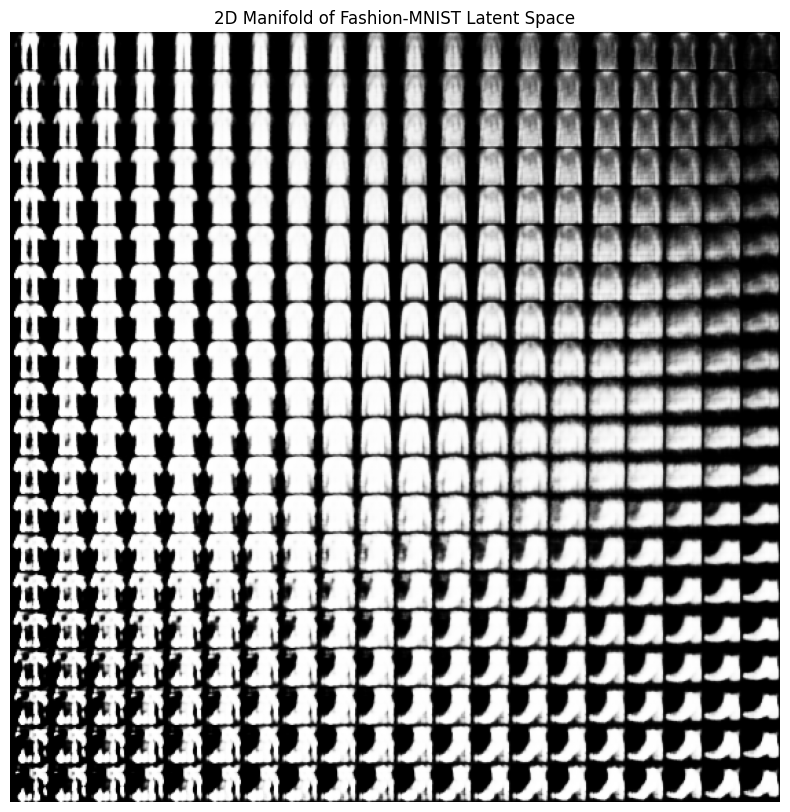

In [6]:
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython import display

# Load Fashion-MNIST
(train_images, _), (test_images, _) = tf.keras.datasets.fashion_mnist.load_data()

def preprocess_images(images):
    images = images.reshape((images.shape[0], 28, 28, 1)) / 255.
    # Generate binary image
    return np.where(images > .5, 1.0, 0.0).astype('float32')

train_images = preprocess_images(train_images)
test_images = preprocess_images(test_images)
train_size = 60000
batch_size = 32
test_size = 10000

# Dataset splitting
train_dataset = (tf.data.Dataset.from_tensor_slices(train_images)
                 .shuffle(train_size).batch(batch_size))
test_dataset = (tf.data.Dataset.from_tensor_slices(test_images)
                .shuffle(test_size).batch(batch_size))

# Define CVAE
# Reference: https://www.tensorflow.org/tutorials/generative/cvae
class CVAE(tf.keras.Model):
    def __init__(self, latent_dim):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer(input_shape=(28, 28, 1)),
            tf.keras.layers.Conv2D(filters=32, kernel_size=3, strides=(2, 2), activation='relu'),
            tf.keras.layers.Conv2D(filters=64, kernel_size=3, strides=(2, 2), activation='relu'),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(latent_dim + latent_dim),
        ])

        self.decoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer(input_shape=(latent_dim,)),
            tf.keras.layers.Dense(units=7*7*32, activation=tf.nn.relu),
            tf.keras.layers.Reshape(target_shape=(7, 7, 32)),
            tf.keras.layers.Conv2DTranspose(filters=64, kernel_size=3, strides=2, padding='same', activation='relu'),
            tf.keras.layers.Conv2DTranspose(filters=32, kernel_size=3, strides=2, padding='same', activation='relu'),
            tf.keras.layers.Conv2DTranspose(filters=1, kernel_size=3, strides=1, padding='same'),
        ])

    @tf.function
    def sample(self, eps=None):
        if eps is None:
            eps = tf.random.normal(shape=(100, self.latent_dim))
        return self.decode(eps, apply_sigmoid=True)

    def encode(self, x):
        mean, logvar = tf.split(self.encoder(x), num_or_size_splits=2, axis=1)
        return mean, logvar

    def reparameterize(self, mean, logvar):
        eps = tf.random.normal(shape=mean.shape)
        return eps * tf.exp(logvar * .5) + mean

    def decode(self, z, apply_sigmoid=False):
        logits = self.decoder(z)
        if apply_sigmoid:
            probs = tf.sigmoid(logits)
            return probs
        return logits

# using adama optimizer SGD
optimizer = tf.keras.optimizers.Adam(1e-4)

def log_normal_pdf(sample, mean, logvar, raxis=1):
    log2pi = tf.math.log(2. * np.pi)
    return tf.reduce_sum(-.5 * ((sample - mean) ** 2. * tf.exp(-logvar) + logvar + log2pi), axis=raxis)

def compute_loss(model, x):
    mean, logvar = model.encode(x)
    z = model.reparameterize(mean, logvar)
    x_logit = model.decode(z)
    cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=x)
    logpx_z = -tf.reduce_sum(cross_ent, axis=[1, 2, 3])
    logpz = log_normal_pdf(z, 0., 0.)
    logqz_x = log_normal_pdf(z, mean, logvar)
    return -tf.reduce_mean(logpx_z + logpz - logqz_x)

@tf.function
def train_step(model, x, optimizer):
    with tf.GradientTape() as tape:
        loss = compute_loss(model, x)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

# Visualizing and Training
epochs = 10
latent_dim = 2
num_examples_to_generate = 16

random_vector_for_generation = tf.random.normal(shape=[num_examples_to_generate, latent_dim])
model = CVAE(latent_dim)

def generate_and_save_images(model, epoch, test_sample):
    mean, logvar = model.encode(test_sample)
    z = model.reparameterize(mean, logvar)
    predictions = model.sample(z)
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0], cmap='gray')
        plt.axis('off')
    plt.suptitle(f'Epoch: {epoch}')
    plt.show()

# Get test sample
for test_batch in test_dataset.take(1):
    test_sample = test_batch[0:num_examples_to_generate, :, :, :]


generate_and_save_images(model, 0, test_sample)

# Training
for epoch in range(1, epochs + 1):
    start_time = time.time()
    for train_x in train_dataset:
        train_step(model, train_x, optimizer)
    end_time = time.time()

    loss = tf.keras.metrics.Mean()
    for test_x in test_dataset:
        loss(compute_loss(model, test_x))
    elbo = -loss.result()

    display.clear_output(wait=False)
    print('Epoch: {}, Test set ELBO: {}, time elapse for current epoch: {:.2f}s'
          .format(epoch, elbo, end_time - start_time))
    generate_and_save_images(model, epoch, test_sample)

# Display a 2D manifold of digits from the latent space
# Reference: https://www.tensorflow.org/tutorials/generative/cvae
def plot_latent_images(model, n, digit_size=28):
    norm = tfp.distributions.Normal(0, 1)
    grid_x = norm.quantile(np.linspace(0.05, 0.95, n))
    grid_y = norm.quantile(np.linspace(0.05, 0.95, n))
    image_width = digit_size*n
    image_height = image_width
    image = np.zeros((image_height, image_width))

    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            z = np.array([[xi, yi]])
            x_decoded = model.sample(z)
            digit = tf.reshape(x_decoded[0], (digit_size, digit_size))
            image[i * digit_size: (i + 1) * digit_size,
                  j * digit_size: (j + 1) * digit_size] = digit.numpy()

    plt.figure(figsize=(10, 10))
    plt.imshow(image, cmap='Greys_r')
    plt.axis('Off')
    plt.title("2D Manifold of Fashion-MNIST Latent Space")
    plt.show()

plot_latent_images(model, 20)

### Part 2 - DCGAN

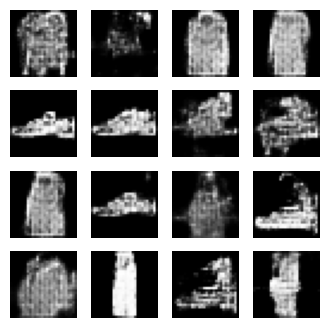

In [7]:
import glob
import imageio
import matplotlib.pyplot as plt
import os
import PIL
from tensorflow.keras import layers
import time
from IPython import display

# Load Fashion MINIST again, only train images and labels needed
(train_images, train_labels), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5

BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# Generator
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))

    return model

# Discriminator
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

generator = make_generator_model()
discriminator = make_discriminator_model()

# loss fn and optimizer
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# Training definition
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal([num_examples_to_generate, noise_dim])

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')
    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()
        for image_batch in dataset:
            train_step(image_batch)

        # Realtime Visualization
        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch + 1, seed)
        print (f'Time for epoch {epoch + 1} is {time.time()-start:.2f} sec')

    display.clear_output(wait=True)
    generate_and_save_images(generator, epochs, seed)


# Training
train(train_dataset, EPOCHS)

In [8]:
!pip install git+https://github.com/tensorflow/docs

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-1js_fj4q
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs /tmp/pip-req-build-1js_fj4q
  Resolved https://github.com/tensorflow/docs to commit 7c3650212740204359d4ceae481abc79345541be
  Preparing metadata (setup.py) ... done
  Created wheel for tensorflow-docs: filename=tensorflow_docs-2026.1.14.40212-py3-none-any.whl size=186922 sha256=51d0d9408302f318e562188b6329db0caf65e00d8ffb5ec9c96098142a4dd66f
  Stored in directory: /tmp/pip-ephem-wheel-cache-9c_cfp0t/wheels/3e/88/34/48d2789bc9d37b33ddce06bccc454fae0285e5396d0a5be9d9
Successfully built tensorflow-docs



Fashion-MNIST Animation:



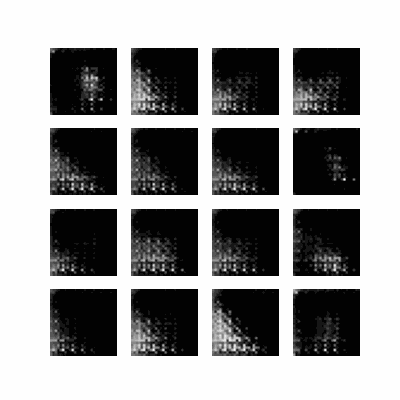

In [9]:

# Generate GIF animation
anim_file = 'dcgan_fashion_mnist.gif'
with imageio.get_writer(anim_file, mode='I') as writer:
    filenames = glob.glob('image*.png')
    filenames = sorted(filenames)
    for filename in filenames:
        image = imageio.v2.imread(filename)
        writer.append_data(image)
    image = imageio.v2.imread(filename)
    writer.append_data(image)

import tensorflow_docs.vis.embed as embed
print("\nFashion-MNIST Animation:")
embed.embed_file(anim_file)

## Task 3
### Part 1 - Attention

In [10]:
def softmax(x, axis=-1):
  e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
  return e_x / np.sum(e_x, axis=axis, keepdims=True)


# Reference: https://github.com/akshaymalik1995/numpy_transformer_tutorial/blob/main/02_scaled_dot_product_attention.md
def scaled_dot_product_attention(q, k, v, mask=None):
  matmul_qk = np.matmul(q, k.swapaxes(-2, -1))

  dk = k.shape[-1]

  # Scale the scores
  scaled_attention_logits = matmul_qk / np.sqrt(dk)

  # Apply Mask
  if mask is not None:
    scaled_attention_logits += (mask * -1e9)

  # Softmax
  attention_weights = softmax(scaled_attention_logits, axis=1)

  # Multiply attention weights by V
  output = np.matmul(attention_weights, v)

  return output, attention_weights


np.random.seed(42)

temp_q = np.random.rand(1, 3, 4)
temp_k = np.random.rand(1, 3, 4)
temp_v = np.random.rand(1, 3, 4)

output, attention_weights = scaled_dot_product_attention(temp_q, temp_k, temp_v)

print("Output Shape:", output.shape)
print("Attention Weights:\n", attention_weights[0])
print("Attention Col Sum\n", np.sum(attention_weights[0], axis=0))

Output Shape: (1, 3, 4)
Attention Weights:
 [[0.35117857 0.3868447  0.3497928 ]
 [0.28407311 0.27305487 0.29460182]
 [0.36474832 0.34010043 0.35560538]]
Attention Col Sum
 [1. 1. 1.]


### Part 2 & Part 3: Seq2Seq with Scaled Dot-Product Attention
Reference: https://www.tensorflow.org/text/tutorials/nmt_with_attention

In [14]:
import tensorflow as tf
import numpy as np
import requests
import zipfile
import os
from tensorflow.keras import layers
import tensorflow_text as tf_text

# Download dataset
url = "http://www.manythings.org/anki/fra-eng.zip"
file_name = "fra-eng.zip"

if not os.path.exists(file_name):
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    response = requests.get(url, headers=headers)
    with open(file_name, 'wb') as f:
        f.write(response.content)
    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        zip_ref.extractall()
    print("Download and extraction complete!")

# Load raw text
num_examples = 10000
lines = open('fra.txt', encoding='UTF-8').read().strip().split('\n')
pairs = [line.split('\t')[:2] for line in lines[:num_examples]]

en_raw = np.array([en for en, fr in pairs])
fr_raw = np.array([fr for en, fr in pairs])

# train test splitting
split_idx = int(0.8 * num_examples)
train_en, test_en = en_raw[:split_idx], en_raw[split_idx:]
train_fr, test_fr = fr_raw[:split_idx], fr_raw[split_idx:]

# Standardization
# Reference: https://www.tensorflow.org/text/tutorials/nmt_with_attention#text_preprocessing
def tf_lower_and_split_punct(text):
    text = tf_text.normalize_utf8(text, 'NFKD')
    text = tf.strings.lower(text)
    text = tf.strings.regex_replace(text, '[^ a-z.?!,]', '')
    text = tf.strings.regex_replace(text, '[.?!,]', r' \0 ')
    text = tf.strings.strip(text)
    text = tf.strings.join(['[START]', text, '[END]'], separator=' ')
    return text


vocab_size = 5000
max_length = 15

input_text_processor = layers.TextVectorization(
    standardize=tf_lower_and_split_punct,
    max_tokens=vocab_size,
    output_sequence_length=max_length)
input_text_processor.adapt(train_en)

target_text_processor = layers.TextVectorization(
    standardize=tf_lower_and_split_punct,
    max_tokens=vocab_size,
    output_sequence_length=max_length)
target_text_processor.adapt(train_fr)

def process_text(context, target):
    context = input_text_processor(context)
    target = target_text_processor(target)

    targ_in = target[:, :-1]
    targ_out = target[:, 1:]
    
    return (context, targ_in), targ_out

BATCH_SIZE = 64

train_raw_ds = tf.data.Dataset.from_tensor_slices((train_en, train_fr)).shuffle(len(train_en)).batch(BATCH_SIZE, drop_remainder=True)
val_raw_ds = tf.data.Dataset.from_tensor_slices((test_en, test_fr)).batch(BATCH_SIZE, drop_remainder=True)

train_ds = train_raw_ds.map(process_text, tf.data.AUTOTUNE)
val_ds = val_raw_ds.map(process_text, tf.data.AUTOTUNE)

#### Encoder-Decoder Implementation

Reference: https://colab.research.google.com/github/tensorflow/text/blob/master/docs/tutorials/nmt_with_attention.ipynb#scrollTo=3rZFgz69nMPa

In [21]:
embedding_dim = 256
units = 512

# Rewrite function due to tensorflow problem
def scaled_dot_product_attention_tf(q, k, v, mask=None):
    matmul_qk = tf.matmul(q, k, transpose_b=True)
    dk = tf.cast(tf.shape(k)[-1], tf.float32)
    scaled_logits = matmul_qk / tf.math.sqrt(dk)

    if mask is not None:
        scaled_logits += (mask * -1e9)

    attention_weights = tf.nn.softmax(scaled_logits, axis=-1)
    output = tf.matmul(attention_weights, v)
    return output, attention_weights

class Encoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, enc_units):
        super(Encoder, self).__init__()
        self.enc_units = enc_units
        # converts tokens to vectors
        self.embedding = layers.Embedding(vocab_size, embedding_dim)

        # RNN layer process vectors sequentially
        self.gru = layers.GRU(self.enc_units,
                              return_sequences=True,
                              return_state=True,
                              recurrent_initializer='glorot_uniform')
    def call(self, x):
        # look up the embedding vector for each token
        x = self.embedding(x)

        # GRU returns (sequence, final_state) when return_state=True
        x, _state = self.gru(x)
        return x

# Luong attention decoder
class Decoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, dec_units):
        super(Decoder, self).__init__()
        self.dec_units = dec_units
        self.embedding = layers.Embedding(vocab_size, embedding_dim)
        self.gru = layers.GRU(self.dec_units, return_sequences=True,
                                        return_state=True, recurrent_initializer='glorot_uniform')

        self.fc = layers.Dense(vocab_size)

    # Reference:
    # https://www.tensorflow.org/text/tutorials/nmt_with_attention
    def call(self, context ,x, state=None, return_state=False):

        # Embedding
        x = self.embedding(x)
        # Shape: bs, 1, embedding_dim

        # GRU Processing
        x, state = self.gru(x, initial_state=state)
        # shape: bs, 1, units

        # RNN output as query for attention computation
        query = x  # (bs, tgt_len, units)
        context_vec, attention_w = scaled_dot_product_attention_tf(query, context, context)

        # Context Vector + decoder outputs
        x = tf.concat([context_vec, query], axis=-1)  # (bs, tgt_len, 2*units)
        logits = self.fc(x)  # (bs, tgt_len, vocab_size)

        if return_state:
            return logits, state

        return logits

encoder = Encoder(vocab_size, embedding_dim, units)
decoder = Decoder(vocab_size, embedding_dim, units)

In [22]:
# Reference:
# https://colab.research.google.com/github/tensorflow/text/blob/master/docs/tutorials/nmt_with_attention.ipynb#scrollTo=WWIyuy71TkJT
class Translator(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, units):
        super().__init__()
        self.encoder = Encoder(vocab_size, embedding_dim, units)
        self.decoder = Decoder(vocab_size, embedding_dim, units)

    def call(self, inputs):
        context, x = inputs
        context = self.encoder(context)
        logits = self.decoder(context, x)

        try:
            del logits._keras_mask
        except AttributeError:
            pass
        return logits
    
model = Translator(vocab_size, embedding_dim, units)


# Train

def masked_loss(y_true, y_pred):
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')
    loss = loss_fn(y_true, y_pred)

    # Ignoring the loss of padding
    mask = tf.cast(y_true != 0, loss.dtype)
    loss *= mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_acc(y_true, y_pred):
    y_pred = tf.cast(tf.argmax(y_pred, axis=-1), y_true.dtype)
    match = tf.cast(y_true == y_pred, tf.float32)
    mask = tf.cast(y_true != 0, tf.float32)
    return tf.reduce_sum(match) / tf.reduce_sum(mask)

model.compile(optimizer='adam', loss=masked_loss, metrics=[masked_acc, masked_loss])
history = model.fit(train_ds, epochs=10)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - loss: 4.3418 - masked_acc: 0.3733 - masked_loss: 4.3418
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - loss: 3.1843 - masked_acc: 0.4676 - masked_loss: 3.1843
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - loss: 2.6367 - masked_acc: 0.5390 - masked_loss: 2.6367
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - loss: 2.2505 - masked_acc: 0.5774 - masked_loss: 2.2505
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - loss: 1.9533 - masked_acc: 0.6085 - masked_loss: 1.9533
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - loss: 1.7173 - masked_acc: 0.6356 - masked_loss: 1.7173
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - loss: 1.5196 - masked_acc: 0.6595 - masked_loss: 1.5196
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - loss: 1.3455 - masked_acc: 0.6850 - masked_loss: 1.3455
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - loss: 1.1921 - masked_acc: 0.7060 - masked_loss: 1.1921


In [25]:
%pip install nltk

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# ID to word
target_vocab = target_text_processor.get_vocabulary()
start_token = target_vocab.index('[START]')
end_token = target_vocab.index('[END]')

def evaluate_sentence(sentence):
    # Preprocessing and Tokenize
    context = input_text_processor(tf.constant([sentence]))

    enc_context = model.encoder(context)
    state = None
    next_token = tf.constant([[start_token]], dtype=tf.int64)
    result_tokens = []
    
    for _ in range(max_length):
        logits, state = model.decoder(enc_context, next_token, state=state, return_state=True)
        
        # Get predicted id with largest prob
        predicted_id = tf.argmax(logits[0, -1, :]).numpy()
        
        # Detect end
        if predicted_id == end_token:
            break
        result_tokens.append(target_vocab[predicted_id])
        
        # Predicted word as input
        next_token = tf.constant([[predicted_id]], dtype=tf.int64)
        
    return ' '.join(result_tokens)


for i in range(5):
    idx = np.random.randint(0, len(test_en))
    raw_en = test_en[idx]
    raw_fr = test_fr[idx]
    
    pred_fr = evaluate_sentence(raw_en)
    print(f"English input: {raw_en}")
    print(f"True French: {raw_fr}")
    print(f"Model Prediction: {pred_fr}\n")


# BLEU for the first 200 samples
smooth_fn = SmoothingFunction().method1
bleu_scores = []

for i in range(min(200, len(test_en))):
    raw_en = test_en[i]
    raw_fr = test_fr[i]
    
    pred_fr = evaluate_sentence(raw_en)
    
    # We also do preprocessing to fr sentences
    processed_ref = tf_lower_and_split_punct(tf.constant(raw_fr)).numpy().decode('utf-8')
    processed_ref = processed_ref.replace('[START] ', '').replace(' [END]', '')
    
    reference = [processed_ref.split()]
    candidate = pred_fr.split()
    
    score = sentence_bleu(reference, candidate, smoothing_function=smooth_fn)
    bleu_scores.append(score)

print(f"\n Keras Seq2Seq (with Attention) has BLEU Score: {np.mean(bleu_scores):.4f}")


English input: It works fine.
True French: Ça marche bien.
Model Prediction: ca peut le faire .

English input: That's a myth.
True French: C'est un mythe.
Model Prediction: cest un phenomene de mode .

English input: I'm not sorry.
True French: Je ne m'excuse pas.
Model Prediction: je ne suis pas abrutie .

English input: It's unlocked.
True French: C'est déverrouillé.
Model Prediction: cest de la nourriture .

English input: That's a fact.
True French: C'est un fait.
Model Prediction: cest un courriel indesirable .


 Keras Seq2Seq (with Attention) has BLEU Score: 0.0982


#### Results

In this part of experiment, we build a Seq2Seq model based on GRU and introduce Scaled Dot-Product Attention. The model has BLEU Score of 0.0982 on validation set by training 10 epoches on 10,000 pairs of english to french translation sentences. 

The model can continuously generate sentence structures that conform to French grammar. 

For example, it has learned to use high‑frequency patterns such as C’est un ("This is a") and Je ne ... pas ("I do not").

The main source of error comes from misalignments at the vocabulary level. For instance, the model translates "That’s a fact" as cest un courriel indesirable ("that’s a spam email").



### Part 4 - Transformer

**Reference**:
- https://www.tensorflow.org/text/tutorials/transformer
- https://www.geeksforgeeks.org/deep-learning/transformer-model-from-scratch-using-tensorflow/

In [74]:
# Reference:
# https://www.tensorflow.org/text/tutorials/transformer#the_embedding_and_positional_encoding_layer
def positional_encoding(length, depth):
    depth = depth / 2
    positions = np.arange(length)[:, np.newaxis]
    depths = np.arange(depth)[np.newaxis, :] / depth
    angle_rates = 1 / (10000**depths)
    angle_rads = positions * angle_rates
    pos_encoding = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)], axis=-1)
    return tf.cast(pos_encoding, dtype=tf.float32)


# 
def create_padding_mask(seq):
    seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
    # align with (batch_size, num_heads, seq_len_q, seq_len_k)
    return seq[:, tf.newaxis, tf.newaxis, :]  

def create_look_ahead_mask(size):
    # simple diagnoal matrix 
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return mask

In [75]:
from tensorflow.keras.layers import Layer, Dense
from tensorflow import reshape, shape, transpose

class MultiHeadAttention(Layer):
    def __init__(self, h, d_model):
        super(MultiHeadAttention, self).__init__()
        self.heads = h
        self.d_model = d_model
        assert d_model % self.heads == 0
        
        # compute the dimension for each head
        self.depth = d_model // self.heads
        
        # map to d_model
        self.wq = Dense(d_model)
        self.wk = Dense(d_model)
        self.wv = Dense(d_model)
        
        # linear layer
        self.dense = Dense(d_model) # wo


    def split_heads(self, x, heads):
        x = reshape(x, shape=(shape(x)[0], shape(x)[1], heads, -1))
        return transpose(x, perm=(0, 2, 1, 3))

    def call(self, q, k, v, mask = None):
        # Linear Projection
        q = self.wq(q)  # (batch_size, seq_len, d_model)
        k = self.wk(k)
        v = self.wv(v)

        q_re = self.split_heads(q, self.heads)
        k_re = self.split_heads(k, self.heads)
        v_re = self.split_heads(v, self.heads)
        
        attn_output, attn_weights = scaled_dot_product_attention_tf(q_re, k_re, v_re, mask)
        
        # Reverting the reshaping and transposing operations: (batch_size, seq_length, d_k)
        concat_attention = tf.transpose(attn_output, perm=[0, 2, 1, 3])
        dynamic_batch_size = tf.shape(concat_attention)[0]
        concat_attention = tf.reshape(concat_attention, (dynamic_batch_size, -1, self.d_model))

        output = self.dense(concat_attention)

        return output, attn_weights

In [76]:
from tensorflow.keras.layers import LayerNormalization, Dropout

# Reference: https://www.tensorflow.org/text/tutorials/transformer#the_feed_forward_network
def feed_forward(d_model, dff):
    return tf.keras.Sequential([
        Dense(dff, activation='relu'),
        Dense(d_model)
    ])


# Reference: https://www.tensorflow.org/text/tutorials/transformer#the_encoder_layer
class EncoderLayer(Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super(EncoderLayer, self).__init__()

        self.mha = MultiHeadAttention(h=num_heads, d_model=d_model)
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)
        self.ffn = feed_forward(d_model, dff)

    def call(self, x, training, mask):
        attn_out, _ = self.mha(x, x, x, mask)
        attn_out = self.dropout1(attn_out, training=training)
        out1 = self.layernorm1(x + attn_out)

        ffn_out = self.ffn(out1)
        ffn_out = self.dropout2(ffn_out, training=training)
        out2 = self.layernorm2(out1 + ffn_out)
        return out2
  
class DecoderLayer(Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super(DecoderLayer, self).__init__()
        self.mha1 = MultiHeadAttention(h=num_heads, d_model=d_model) # Masked self-attention
        self.mha2 = MultiHeadAttention(h=num_heads, d_model=d_model) # Cross-attention
        self.ffn = feed_forward(d_model, dff)

        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.layernorm3 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)
        self.dropout3 = Dropout(dropout_rate)

    def call(self, x, enc_output, training, look_ahead_mask, padding_mask):
        # Masked self-atten
        attn1, _ = self.mha1(x, x, x, look_ahead_mask)  
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(attn1 + x)
        
        # Cross attention
        attn2, _ = self.mha2(out1, enc_output, enc_output, padding_mask)  
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(attn2 + out1)
        
        # feed forward
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        out3 = self.layernorm3(ffn_output + out2)
        return out3

In [77]:
from tensorflow.keras.layers import Embedding, Layer, Dropout, Dense
import tensorflow as tf

# Reference: https://www.tensorflow.org/text/tutorials/transformer#the_encoder
# https://www.geeksforgeeks.org/deep-learning/transformer-model-from-scratch-using-tensorflow/
class Encoder(Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, vocab_size, dropout_rate=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = Embedding(vocab_size, d_model)
        self.pos_encoding = positional_encoding(2048, self.d_model)

        self.enc_layers = [EncoderLayer(d_model, num_heads, dff, dropout_rate) for _ in range(num_layers)]
        self.dropout = Dropout(dropout_rate)

    def call(self, x, training=False, mask=None):
        # Position embedding
        seq_len = tf.shape(x)[1]
        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_encoding[tf.newaxis, :seq_len, :]

        # Add dropout
        x = self.dropout(x, training=training)
        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training=training, mask=mask)
        return x

# Reference: https://www.tensorflow.org/text/tutorials/transformer#the_decoder
# https://www.geeksforgeeks.org/deep-learning/transformer-model-from-scratch-using-tensorflow/
class Decoder(Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, vocab_size, dropout_rate=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model
        self.num_layers = num_layers
        self.embedding = Embedding(vocab_size, d_model)
        self.pos_encoding = positional_encoding(2048, self.d_model)
        self.dec_layers = [DecoderLayer(d_model, num_heads, dff, dropout_rate) for _ in range(num_layers)]
        self.dropout = Dropout(dropout_rate)

    def call(self, x, enc_output, training=False, look_ahead_mask=None, padding_mask=None):
        seq_len = tf.shape(x)[1]

        # Position Embedding
        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_encoding[tf.newaxis, :seq_len, :]

        # Add Dropout
        x = self.dropout(x, training=training)
        for i in range(self.num_layers):
            x = self.dec_layers[i](x, enc_output, training=training, look_ahead_mask=look_ahead_mask, padding_mask=padding_mask) 
        return x # The shape of x is (batch_size, target_seq_len, d_model).

# Reference: https://www.tensorflow.org/text/tutorials/transformer#the_transformer
# https://www.geeksforgeeks.org/deep-learning/transformer-model-from-scratch-using-tensorflow/
class Transformer(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, target_vocab_size, dropout_rate=0.1):
        super(Transformer, self).__init__()

        # Combines Encoder and Decoder
        self.encoder = Encoder(num_layers, d_model, num_heads, dff, input_vocab_size, dropout_rate)
        self.decoder = Decoder(num_layers, d_model, num_heads, dff, target_vocab_size, dropout_rate)

        # Softmax
        self.final_layer = Dense(target_vocab_size, activation='softmax')

    def call(self, inputs, training=False):
        inp, tar = inputs
        # Apply mask
        enc_padding_mask = create_padding_mask(inp)
        dec_padding_mask = create_padding_mask(inp)
        
        look_ahead_mask = create_look_ahead_mask(tf.shape(tar)[1])
        dec_target_padding_mask = create_padding_mask(tar)
        combined_mask = tf.maximum(dec_target_padding_mask, look_ahead_mask)
        
        enc_output = self.encoder(inp, training=training, mask=enc_padding_mask) 
        dec_output = self.decoder(tar, enc_output, training=training, look_ahead_mask=combined_mask, padding_mask=dec_padding_mask)
        
        final_output = self.final_layer(dec_output)
        return final_output

In [78]:
# Defining Custom Parameters.
num_layers = 2
d_model = 64
num_heads = 2
dff = 128

transformer = Transformer(
    num_layers,
    d_model,
    num_heads,
    dff,
    vocab_size,
    vocab_size,
)
def loss_function(real, pred):
    # Set from_logits to False
    loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction='none')
    loss_ = loss_object(real, pred)

    mask = tf.math.logical_not(tf.math.equal(real, 0))
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask
    return tf.reduce_sum(loss_) / tf.reduce_sum(mask)

def accuracy_function(real, pred):
    accuracies = tf.math.equal(tf.cast(real, tf.int64), tf.argmax(pred, axis=2))
    mask = tf.math.logical_not(tf.math.equal(real, 0))

    accuracies = tf.math.logical_and(mask, accuracies)
    accuracies = tf.cast(accuracies, dtype=tf.float32)
    
    mask = tf.cast(mask, dtype=tf.float32)
    return tf.reduce_sum(accuracies) / tf.reduce_sum(mask)

In [80]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
transformer.compile(loss=loss_function, optimizer=optimizer, metrics=[accuracy_function])


transformer.fit(train_ds, epochs=20)

def evaluation(sentence):
    context = input_text_processor(tf.constant([sentence]))  # (1, src_len)

    output_array = tf.TensorArray(dtype=tf.int64, size=0, dynamic_size=True)
    output_array = output_array.write(0, tf.constant(start_token, dtype=tf.int64))  # scalar

    for i in tf.range(max_length):
        # (1, cur_len)  <-- 2D, what the decoder expects
        output = tf.expand_dims(output_array.stack(), axis=0)

        predictions = transformer((context, output), training=False)  # (1, cur_len, vocab)
        predicted_id = tf.argmax(predictions[:, -1, :], axis=-1, output_type=tf.int64)  # (1,)

        if predicted_id[0] == end_token:
            break

        output_array = output_array.write(i + 1, predicted_id[0])  # scalar

    output_ids = output_array.stack().numpy()  # (len,)
    result_tokens = [target_vocab[idx] for idx in output_ids[1:]]
    return " ".join(result_tokens)


smooth_fn = SmoothingFunction().method1
simplified_bleu_scores = []

for i in range(min(200, len(test_en))):
    raw_en = test_en[i]
    raw_fr = test_fr[i]
    
    pred_fr = evaluation(raw_en)
    processed_ref = tf_lower_and_split_punct(tf.constant(raw_fr)).numpy().decode('utf-8')
    processed_ref = processed_ref.replace('[START] ', '').replace(' [END]', '')
    
    reference = [processed_ref.split()]
    candidate = pred_fr.split()
    
    score = sentence_bleu(reference, candidate, smoothing_function=smooth_fn)
    simplified_bleu_scores.append(score)

print(f"\n Transformer has BLEU Score: {np.mean(simplified_bleu_scores):.4f}")

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 12ms/step - accuracy_function: 0.8096 - loss: 0.6313
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy_function: 0.8228 - loss: 0.5707
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy_function: 0.8259 - loss: 0.5439
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy_function: 0.8308 - loss: 0.5185
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy_function: 0.8308 - loss: 0.4991
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy_function: 0.8337 - loss: 0.4919
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy_function: 0.8352 - loss: 0.4766
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy_function: 0.8367 - loss: 0.4660
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy_function: 0.8391 - loss: 0.4563
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy_function: 0.8409 - loss: 0.4428
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━

### Evaluation & Discussion

**Performance Comparison:**
- **RNN + Attention:** ~0.098
- **Transformer:** ~0.169
- The simplified Transformer significantly outperformed the RNN based Seq2Seq model. Even though we heavily simplfy the orginal Transformer (using $d_{model}=64$, $H=2$, and $L=2$), the self-attention mechanism is highly effective at capturing long-range and bidirectional context. While GRU usually compressing past sequences into a single hidden state.

**Differences:**

A major difference observed was the training runtime. The RNN model must process tokens sequentially ($t_1 \rightarrow t_2 \rightarrow t_3$). In contrast, the Transformer completed each epoch in just 1 to 2 seconds.Transformer use the Look-Ahead Mask in the decoder, it could compute attention for all tokens in the entire target sequence simultaneously via matrix multiplications ($O(1)$ sequential operations). 